# Depandancy Package

In [87]:
import numpy as np
import matplotlib.pyplot as plt

# ADALINE

In [88]:
class adaline():
    """
    Linear Model train with Gradient Descent as optimizer with MSE as criteria (aka the LMS).

    The optimization objective for Lasso is:
    (1 / n_samples) * ||y - Xw||^2_2

    Parameters
    ----------
    lr: learning rate for weight update
    epochs: iterative run for training
    """
    def __init__(self, lr=0.01, epochs=100):
        self.learning_rate = lr
        self.epochs = epochs
        self.w = None
        self.acc_train_hist = []
        self.acc_test_hist = []
        self.loss_train_hist = []
        self.loss_test_hist = []
        self.mean = None
        self.std = None
        pass

    def MSE(self, y, x, w):
        y_hat = x@w
        error = y - y_hat
        return np.sum(error ** 2)/np.shape(x)[0]

    def fit(self, X, Y):
        # Augmentation
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        eta = 1e-9
        X = (X - self.mean) / (self.std+eta)

        rgen = np.random.RandomState(42)
        self.w = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1]) # bias + weights
        X = np.insert(X, 0, 1, axis=1) # 在X前面增加一行1

        # Data Splitting
        indices = np.random.permutation(X.shape[0])
        train_idx, test_idx = indices[:80], indices[80:] # 80% 訓練, 20% 測試
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = Y[train_idx], Y[test_idx]

        N_train = np.shape(X_train)[0]
        P_train = np.shape(X_test)[1]
        N_test = np.shape(X_test)[0]
        P_test = np.shape(X_test)[1]
        for epoch in range(self.epochs):
            # training
            gradient = ((-2)/N_train)*np.transpose(X_train)@(y_train-X_train@self.w)
            self.w = self.w - self.learning_rate*gradient
            loss = self.MSE(y_train, X_train, self.w)
            self.loss_train_hist.append(loss)
            y_hat = X_train@self.w
            y_hat = np.where(y_hat >= 0, 1, -1)
            equal_count = np.sum(y_train == y_hat)
            accuracy = np.round((equal_count / len(y_train)) * 100, 1)
            self.acc_train_hist.append(accuracy)
            # testing
            loss = self.MSE(y_test, X_test, self.w)
            self.loss_test_hist.append(loss)
            y_hat = X_test@self.w
            y_hat = np.where(y_hat >= 0, 1, -1)
            equal_count = np.sum(y_test == y_hat)
            accuracy = np.round((equal_count / len(y_test)) * 100, 1)
            self.acc_test_hist.append(accuracy)

    def predict(self, X):
        # Augmentation
        X_mean = np.mean(X, axis=0)
        X_std = np.std(X, axis=0)
        # print(f"training mean: {self.mean}, predict mean: {X_mean}")
        # print(f"training std: {self.std}, predict mean: {X_std}")
        eta = 1e-9
        X = (X - self.mean) / (self.std+eta)
        # 把bias合進去X
        X = np.insert(X, 0, 1, axis=1) # 在X前面增加一行1
        # Predict
        y_hat = X@self.w
        y_hat = np.where(y_hat >= 0, 1, -1)
        return y_hat

# Training & Testing

In [89]:
# 固定隨機種子，確保你跑出來的結果跟我一樣
np.random.seed(42)

N = 50
P = 2
std = 1.5

# 1. 產生第一類資料 (Label: -1) - 集中在左下角
X1 = np.random.normal(loc=2, scale=std, size=(N, P))
y1 = np.ones(N) * -1

# 2. 產生第二類資料 (Label: 1) - 集中在右上角
X2 = np.random.normal(loc=4, scale=std, size=(N, P))
y2 = np.ones(N) * 1

# 3. 合併資料
X = np.vstack((X1, X2))
y = np.concatenate((y1, y2))

model = adaline(epochs=250)
model.fit(X,y)

# 4. 檢查權重
if not np.all(np.isfinite(model.w)):
    print("Weight error")
    print(model.w)

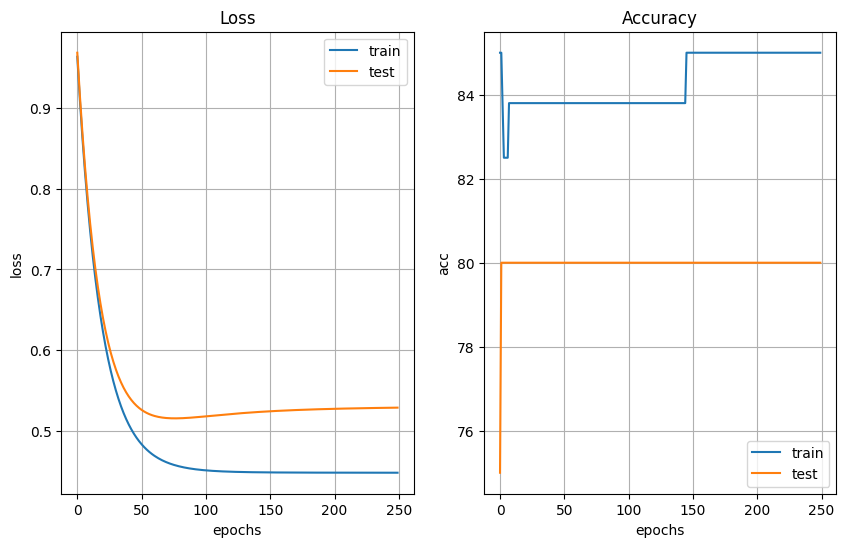

In [90]:
fig, ax = plt.subplots(1,2, figsize=(10, 6))
ax[0].plot(model.loss_train_hist, label='train')
ax[0].plot(model.loss_test_hist, label='test')
ax[0].grid()
ax[0].set_xlabel(f"epochs")
ax[0].set_ylabel(f"loss")
ax[0].set_title("Loss")
ax[0].legend()

ax[1].plot(model.acc_train_hist, label='train')
ax[1].plot(model.acc_test_hist, label='test')
ax[1].grid()
ax[1].set_xlabel(f"epochs")
ax[1].set_ylabel(f"acc")
ax[1].set_title("Accuracy")
ax[1].legend()

plt.show()

In [91]:
# 重新產生同樣分布的資料測試
# 1. 產生第一類資料 (Label: -1) - 集中在左下角
N = 1
X1 = np.random.normal(loc=2, scale=0.5, size=(N, 2))
y1 = np.ones(N) * -1
y1_hat = model.predict(X=X1)
equal_count = np.sum(y1 == y1_hat)
equal_count = equal_count*1.0
accuracy = equal_count / len(y1)
print(accuracy)

# 2. 產生第二類資料 (Label: 1) - 集中在右上角
X2 = np.random.normal(loc=4, scale=0.5, size=(N, 2))
y2 = np.ones(N) * 1
y2_hat = model.predict(X=X2)
equal_count = np.sum(y2 == y2_hat)
equal_count = equal_count*1.0
accuracy = equal_count / len(y2)
print(accuracy)

1.0
1.0


# Feature Visualization

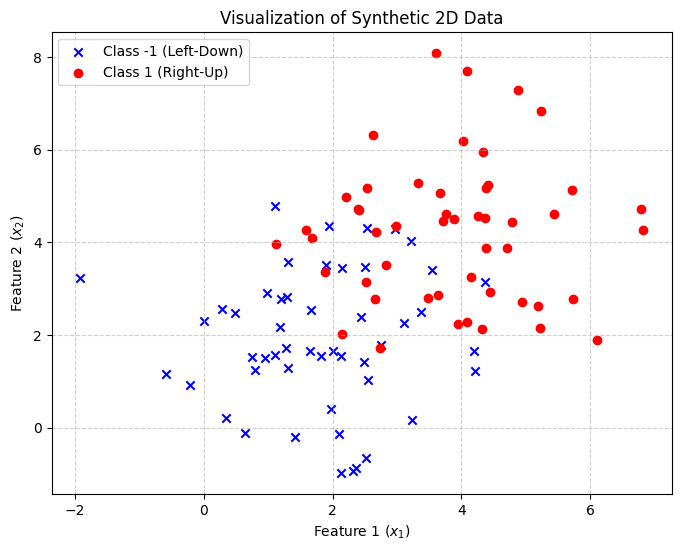

Total samples: 100


In [92]:
# --- 繪圖視覺化 ---
plt.figure(figsize=(8, 6))

# 畫出類別 -1 的點 (利用布林索引)
plt.scatter(X[y == -1, 0], X[y == -1, 1],
            color='blue', marker='x', label='Class -1 (Left-Down)')

# 畫出類別 1 的點
plt.scatter(X[y == 1, 0], X[y == 1, 1],
            color='red', marker='o', label='Class 1 (Right-Up)')

plt.xlabel('Feature 1 ($x_1$)')
plt.ylabel('Feature 2 ($x_2$)')
plt.title('Visualization of Synthetic 2D Data')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Total samples: {len(X)}")